In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt
import itertools
import numpy as np
import holidays



In [ ]:
# Cargamos el dataset, asumiendo que la primera columna es la marca de tiempo
                                                                   

In [56]:
# Renombramos target a 'y' y creamos 'ds'
df = df.rename(columns={'timestamp':'ds', 'consumo_kWh':'y'})

# 2. Limpieza inicial
# Eliminamos columnas sin información o muy redundantes
df = df.drop(columns=['altitud','tmed','tmin','tmax'])

In [57]:
# 3. Ingeniería de regresores
# Lags de consumo
for lag in [1, 24, 168]:
    df[f'lag_{lag}'] = df['y'].shift(lag)

# Medias móviles (usando sólo datos previos)
for window in [3, 6, 24]:
    df[f'rollmean_{window}'] = df['y'].shift(1).rolling(window).mean()

# Tendencia semanal (diff vs media última semana)
df['week_avg'] = df['y'].shift(1).rolling(168).mean()
df['trend_diff'] = df['y'] - df['week_avg']

# Eliminamos filas con NaN generados
df_model = df.dropna().reset_index(drop=True)

In [58]:
# 1. Separar los últimos 3 días para simular el futuro
n_hours = 3 * 24
df_future = df_model.tail(n_hours).reset_index(drop=True).copy()
df_train  = df_model.iloc[:-n_hours].reset_index(drop=True).copy()

In [59]:
future_data = df_future.copy()

In [60]:
# 2. Prepara parámetros finales (hardcodeado)
best_params = {
    'changepoint_prior_scale': 0.1,
    'seasonality_prior_scale': 10.0,
    'seasonality_mode': 'additive'
}
final_regs = [
    'lag_1', 'lag_24', 'lag_168',
    'rollmean_3', 'rollmean_6', 'rollmean_24',
    'trend_diff',
    'temperatura', 'velmedia', 'sol', 'presMax', 'prec_valor'
]


In [61]:
# ==============================
# 4. Holidays centrados en Barcelona (Cataluña)
# ==============================
# Generamos el calendario de festivos de España, provincia CT (Cataluña)
date = pd.to_datetime(df_model['ds'])
years = range(date.dt.year.min(), date.dt.year.max()+1)
spain_ct = holidays.Spain(prov='CT', years=years)
holiday_df = pd.DataFrame([
    {'ds': pd.to_datetime(day), 'holiday': name}
    for day, name in spain_ct.items()
])

In [62]:
# 3. Simulación rolling forecast
preds = []
for i, row in df_future.iterrows():
    # 3.1 Configura y entrena el modelo
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True,
        holidays=holiday_df,
        **best_params
    )
    for r in final_regs:
        m.add_regressor(r)
    m.fit(df_train[['ds','y'] + final_regs])

    # 3.2 Prepara la fila a predecir (ya con todos los regresores calculados en df_future)
    df_pred = pd.DataFrame([{'ds': row['ds'], **{r: row[r] for r in final_regs}}])

    # 3.3 Predicción
    fc = m.predict(df_pred)
    preds.append({
        'ds':         row['ds'],
        'y_true':     row['y'],
        'yhat':       fc.loc[0, 'yhat'],
        'yhat_low':   fc.loc[0, 'yhat_lower'],
        'yhat_high':  fc.loc[0, 'yhat_upper']
    })

    # 3.4 Añade la observación real a df_train (“reentrenamiento” incremental)
    df_train = pd.concat([df_train, row.to_frame().T], ignore_index=True)

18:40:19 - cmdstanpy - INFO - Chain [1] start processing
18:40:58 - cmdstanpy - INFO - Chain [1] done processing
18:40:59 - cmdstanpy - INFO - Chain [1] start processing
18:41:34 - cmdstanpy - INFO - Chain [1] done processing
18:41:34 - cmdstanpy - INFO - Chain [1] start processing
18:42:21 - cmdstanpy - INFO - Chain [1] done processing
18:42:21 - cmdstanpy - INFO - Chain [1] start processing
18:42:50 - cmdstanpy - INFO - Chain [1] done processing
18:42:50 - cmdstanpy - INFO - Chain [1] start processing
18:43:35 - cmdstanpy - INFO - Chain [1] done processing
18:43:36 - cmdstanpy - INFO - Chain [1] start processing
18:44:13 - cmdstanpy - INFO - Chain [1] done processing
18:44:13 - cmdstanpy - INFO - Chain [1] start processing
18:44:49 - cmdstanpy - INFO - Chain [1] done processing
18:44:50 - cmdstanpy - INFO - Chain [1] start processing
18:45:19 - cmdstanpy - INFO - Chain [1] done processing
18:45:20 - cmdstanpy - INFO - Chain [1] start processing
18:45:56 - cmdstanpy - INFO - Chain [1]

RMSE@1h sobre 3 días: 2.1917
MAE@1h   sobre 3 días: 1.8852


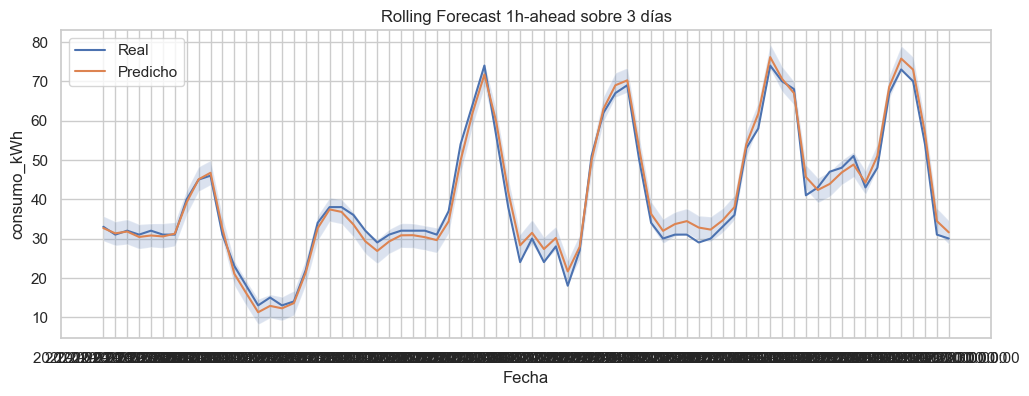

In [64]:
# 4. Resultado de las predicciones
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error


df_preds = pd.DataFrame(preds)
# Compute RMSE manually if 'squared' argument is not available
rmse = np.sqrt(mean_squared_error(df_preds['y_true'], df_preds['yhat']))
mae  = mean_absolute_error(df_preds['y_true'], df_preds['yhat'])
print(f"RMSE@1h sobre 3 días: {rmse:.4f}")
print(f"MAE@1h   sobre 3 días: {mae:.4f}")

# 5. Gráfica comparativa
plt.figure(figsize=(12,4))
plt.plot(df_preds['ds'], df_preds['y_true'], label='Real')
plt.plot(df_preds['ds'], df_preds['yhat'],   label='Predicho')
plt.fill_between(df_preds['ds'],
                 df_preds['yhat_low'],
                 df_preds['yhat_high'],
                 alpha=0.2)
plt.title('Rolling Forecast 1h-ahead sobre 3 días')
plt.xlabel('Fecha')
plt.ylabel('consumo_kWh')
plt.legend()
plt.show()